# PatchTST Post-Training Evaluation & Backtest

**Purpose:** Validate that saved model performance is genuine, not an artifact of pipeline bugs.
This notebook is entirely read-only with respect to the model -- it never trains or fine-tunes.

Sections:
1. Environment setup, seeds, version logging
2. Load saved checkpoint + training metadata
3. Rebuild train/valid/test datasets deterministically
4. Bias & pipeline audit
5. Extended evaluation metrics
6. Reproducibility checks
7. Year-stability backtest
8. Optimization-metric recommendation
9. Persist `eval_report.json`

## 0. Environment Setup

In [1]:
# Uncomment on Kaggle if packages are missing:
# %pip install -q transformers accelerate scikit-learn seaborn

In [2]:
import json
import random
import subprocess
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    f1_score,
)
from torch.utils.data import DataLoader
from transformers import PatchTSTConfig

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid')

# ---------------------------------------------------------------------------
# Determinism -- must be set before any torch/numpy operations.
# ---------------------------------------------------------------------------
SEED = 42

def set_seeds(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(SEED)

try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass  # older torch versions do not support this flag

# ---------------------------------------------------------------------------
# Environment detection: Kaggle vs local.
# ---------------------------------------------------------------------------
IS_KAGGLE = Path('/kaggle/input').exists()

if IS_KAGGLE:
    REPO_URL    = 'https://github.com/AntonyAPT/SeniorProject.git'
    REPO_BRANCH = 'feature/zamnz_patchTST_weight_decay'
    REPO_DIR    = Path('/kaggle/working/SeniorProject')
    if not REPO_DIR.exists():
        subprocess.run(
            ['git', 'clone', '--depth', '1', '--branch', REPO_BRANCH, REPO_URL, str(REPO_DIR)],
            check=True,
        )
    MODELS_DIR   = REPO_DIR / 'models'
    NOTEBOOK_DIR = MODELS_DIR / 'notebooks' / 'technical'
    DATA_RAW_DIR = Path('/kaggle/input/datasets/kingz101/sp500-daily-raw')
    SAVE_DIR = Path('/kaggle/input/datasets/kingz101/patchtst-saved-model')
else:
    NOTEBOOK_DIR = Path.cwd()
    if NOTEBOOK_DIR.name != 'technical':
        NOTEBOOK_DIR = Path('models/notebooks/technical').resolve()
    MODELS_DIR   = NOTEBOOK_DIR.parents[1]   # models/
    DATA_RAW_DIR = MODELS_DIR / 'data_raw'
    SAVE_DIR     = NOTEBOOK_DIR / 'save_dir'

# Add models/ to sys.path so `import patchtst_lib.*` works.
sys.path.insert(0, str(MODELS_DIR))

from patchtst_lib.classification_head import PatchTSTClassifier
from patchtst_lib.technical.dataset import (
    StockWindowClassificationDataset,
    split_by_fraction,
    summarize_dataset,
)
from patchtst_lib.labeling import LabelConfig
import patchtst_lib.technical.backtest as bt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device={device}')


Cloning into '/kaggle/working/SeniorProject'...


Environment : Kaggle
Device      : cuda
NOTEBOOK_DIR: /kaggle/working/SeniorProject/models/notebook
DATA_RAW_DIR: /kaggle/input/datasets/kingz101/sp500-daily-raw
SAVE_DIR    : /kaggle/input/datasets/kingz101/patchtst-saved-model

Package versions:
  run_timestamp_utc      2026-05-18T02:41:46+00:00
  python                 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
  torch                  2.10.0+cu128
  transformers           5.0.0
  numpy                  2.0.2
  pandas                 2.3.3
  sklearn                1.6.1
  device                 cuda
  cuda_available         True
  seed                   42
  is_kaggle              True


## 1. Load Saved Artifact

In [3]:
# ---------------------------------------------------------------------------
# The artifact directory to evaluate.  All config is read from the saved
# training_metadata.json so this cell cannot drift from the trained model.
# ---------------------------------------------------------------------------
ARTIFACT_SCOPE_SLUG = 'all_11_sectors'
ARTIFACT_DIR = SAVE_DIR / f'patchtst_cls_sector_{ARTIFACT_SCOPE_SLUG}'
CHECKPOINT_PATH  = ARTIFACT_DIR / 'pytorch_model.bin'
METADATA_PATH    = ARTIFACT_DIR / 'training_metadata.json'

for p in [ARTIFACT_DIR, CHECKPOINT_PATH, METADATA_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f'Expected artifact at {p}. '
            'Pull the saved files from Kaggle or adjust ARTIFACT_SCOPE_SLUG.'
        )

with open(METADATA_PATH) as f:
    META = json.load(f)

CONTEXT_LENGTH      = int(META['context_length'])
FORECAST_HORIZON    = int(META['forecast_horizon'])
LABEL_RULE          = META['label_rule']
LABEL_THRESHOLD     = float(META['label_threshold'])
TARGET_COLUMNS      = META['target_columns'].split(',')
NUM_INDUSTRIES      = int(META.get('num_industries', 0))
INDUSTRY_EMB_DIM    = int(META.get('industry_embedding_dim', 8))
SAVED_SECTORS       = META.get('sectors', '').split(',')
N_CLASSES           = 3
TRAIN_FRAC          = 0.8
VALID_FRAC          = 0.1
BATCH_SIZE          = 64
TIMESTAMP_COLUMN    = 'Date'
TICKER_COLUMN       = 'Ticker'
SECTOR_COLUMN       = 'Sector'
HISTORIC_CSV        = DATA_RAW_DIR / 'historic_data_rows.csv'

label_config = LabelConfig(
    rule=LABEL_RULE,
    threshold=LABEL_THRESHOLD,
    vol_window=21,
    vol_k=0.5,
)

print('Loaded training_metadata.json')
print(f'  context_length   : {CONTEXT_LENGTH}')
print(f'  forecast_horizon : {FORECAST_HORIZON}')
print(f'  label_rule       : {LABEL_RULE}  threshold={LABEL_THRESHOLD}')
print(f'  target_columns   : {TARGET_COLUMNS}')
print(f'  num_industries   : {NUM_INDUSTRIES}  emb_dim={INDUSTRY_EMB_DIM}')
print(f'  sectors          : {SAVED_SECTORS}')

# ---------------------------------------------------------------------------
# Re-build the model from config + state_dict.  class_weights are not used
# at eval time (loss computation is disabled when labels are not passed).
# ---------------------------------------------------------------------------
reloaded_config = PatchTSTConfig.from_pretrained(ARTIFACT_DIR)
model = PatchTSTClassifier(
    config=reloaded_config,
    horizon=FORECAST_HORIZON,
    n_classes=N_CLASSES,
    class_weights=None,
    num_industries=NUM_INDUSTRIES,
    industry_embedding_dim=INDUSTRY_EMB_DIM,
)
state_dict = torch.load(CHECKPOINT_PATH, map_location='cpu')
model.load_state_dict(state_dict, strict=False)
model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'\nModel loaded: {total_params:,} parameters  ({CHECKPOINT_PATH.stat().st_size / 1e6:.1f} MB)')

Loaded training_metadata.json
  context_length   : 128
  forecast_horizon : 5
  label_rule       : rolling_vol  threshold=0.01
  target_columns   : ['Open', 'High', 'Low', 'Close', 'Volume']
  num_industries   : 111  emb_dim=8
  sectors          : ['Communication Services', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Information Technology', 'Materials', 'Real Estate', 'Utilities']

Model loaded: 906,254 parameters  (3.7 MB)


## 2. Rebuild Datasets Deterministically

The splits and scaler stats are rebuilt from scratch using the identical logic
as the training notebook.  No randomness beyond the fixed seed.

In [4]:
import re

_CANONICAL_LOWER = {
    'date': TIMESTAMP_COLUMN, 'ticker': TICKER_COLUMN,
    'open': 'Open', 'high': 'High', 'low': 'Low',
    'close': 'Close', 'volume': 'Volume', 'sector': SECTOR_COLUMN,
}

def _normalize_historic_columns(frame: pd.DataFrame) -> pd.DataFrame:
    rename = {c: _CANONICAL_LOWER[c.strip().lower()]
              for c in frame.columns if c.strip().lower() in _CANONICAL_LOWER}
    out = frame.rename(columns=rename)
    out[TIMESTAMP_COLUMN] = pd.to_datetime(out[TIMESTAMP_COLUMN])
    return out

if not HISTORIC_CSV.exists():
    raise FileNotFoundError(f'Missing {HISTORIC_CSV}')

raw_df = _normalize_historic_columns(pd.read_csv(HISTORIC_CSV))
raw_df = raw_df[raw_df[TIMESTAMP_COLUMN] >= '2015-01-01'].copy()

# Filter to the same sectors the model was trained on.
available_sectors = sorted(str(s) for s in raw_df[SECTOR_COLUMN].dropna().unique())
active_sectors = [s for s in available_sectors if s in SAVED_SECTORS] or available_sectors
raw_df = raw_df[raw_df[SECTOR_COLUMN].isin(active_sectors)].copy()
raw_df = raw_df.sort_values([TICKER_COLUMN, TIMESTAMP_COLUMN]).reset_index(drop=True)
raw_df[TICKER_COLUMN] = raw_df[TICKER_COLUMN].astype(str)
raw_df[SECTOR_COLUMN]  = raw_df[SECTOR_COLUMN].astype(str)
raw_df['Volume']       = np.log1p(raw_df['Volume'].astype(float))

print(f'Raw data: {len(raw_df):,} rows | {raw_df[TICKER_COLUMN].nunique()} tickers | {len(active_sectors)} sectors')
print(f'Date range: {raw_df[TIMESTAMP_COLUMN].min().date()} -> {raw_df[TIMESTAMP_COLUMN].max().date()}')

Raw data: 1,386,631 rows | 503 tickers | 11 sectors
Date range: 2015-01-02 -> 2026-05-01


In [5]:
# ---------------------------------------------------------------------------
# Industry mapping -- loaded from disk (same file training used).
# ---------------------------------------------------------------------------
_industry_map_path = NOTEBOOK_DIR / 'ticker_industry.json'

if _industry_map_path.exists():
    with open(_industry_map_path) as _f:
        TICKER_INDUSTRY = json.load(_f)
    print(f'Loaded TICKER_INDUSTRY: {len(TICKER_INDUSTRY)} tickers, '
          f'{len(set(TICKER_INDUSTRY.values()))} unique industries')
else:
    TICKER_INDUSTRY = {}
    print('ticker_industry.json not found -- industry embedding will be zeroed.')

Loaded TICKER_INDUSTRY: 503 tickers, 111 unique industries


In [6]:
# ---------------------------------------------------------------------------
# Identical split + per-ticker standardization as the training notebook.
# Scaler stats are fit on train only -- verified in the audit section.
# ---------------------------------------------------------------------------
def manual_per_ticker_standardize(train_df, valid_df, test_df, target_columns,
                                   ticker_column='Ticker'):
    """Fit scaler on train only; apply to all three splits."""
    stats = {}
    for ticker, group in train_df.groupby(ticker_column):
        mean = group[target_columns].astype(float).mean()
        std  = group[target_columns].astype(float).std().replace(0, 1.0).fillna(1.0)
        stats[str(ticker)] = (mean, std)
    global_mean = train_df[target_columns].astype(float).mean()
    global_std  = train_df[target_columns].astype(float).std().replace(0, 1.0).fillna(1.0)

    def transform(frame):
        frame = frame.copy()
        for ticker, idx in frame.groupby(ticker_column).groups.items():
            m, s = stats.get(str(ticker), (global_mean, global_std))
            frame.loc[idx, target_columns] = (frame.loc[idx, target_columns].astype(float) - m) / s
        return frame

    return transform(train_df), transform(valid_df), transform(test_df), stats


set_seeds(SEED)  # ensure identical split regardless of upstream pandas ops
train_raw, valid_raw, test_raw = split_by_fraction(
    raw_df,
    train_frac=TRAIN_FRAC,
    valid_frac=VALID_FRAC,
    timestamp_column=TIMESTAMP_COLUMN,
    ticker_column=TICKER_COLUMN,
    context_length=CONTEXT_LENGTH,
)

train_values, valid_values, test_values, scaler_stats = manual_per_ticker_standardize(
    train_raw, valid_raw, test_raw, TARGET_COLUMNS, TICKER_COLUMN
)

train_ds = StockWindowClassificationDataset(
    train_values, train_raw, TARGET_COLUMNS, CONTEXT_LENGTH, FORECAST_HORIZON,
    label_config, ticker_industry=TICKER_INDUSTRY,
)
valid_ds = StockWindowClassificationDataset(
    valid_values, valid_raw, TARGET_COLUMNS, CONTEXT_LENGTH, FORECAST_HORIZON,
    label_config, ticker_industry=TICKER_INDUSTRY,
    industry_to_id=train_ds.industry_to_id,
)
test_ds = StockWindowClassificationDataset(
    test_values, test_raw, TARGET_COLUMNS, CONTEXT_LENGTH, FORECAST_HORIZON,
    label_config, ticker_industry=TICKER_INDUSTRY,
    industry_to_id=train_ds.industry_to_id,
)

dataset_summary = pd.concat([
    summarize_dataset('train', train_ds),
    summarize_dataset('valid', valid_ds),
    summarize_dataset('test',  test_ds),
], ignore_index=True)
print(dataset_summary.to_string(index=False))

dataset  windows    down    flat      up  down_pct  flat_pct   up_pct
  train  1042830 1680848 1476632 2056670  0.322363  0.283197 0.394440
  valid   136686  225859  191857  265714  0.330479  0.280727 0.388795
   test   136706  221312  200176  262042  0.323778  0.292856 0.383366


## 3. Bias & Pipeline Audit

Each item below is a concrete, executable assertion with printed evidence.
A test failure raises an `AssertionError`; silence = pass.

In [7]:
print('=' * 60)
print('AUDIT 1 -- Scaling uses train statistics only')
print('=' * 60)

sample_tickers = sorted(scaler_stats.keys())[:3]
for t in sample_tickers:
    mean_t, std_t = scaler_stats[t]
    train_group = train_raw[train_raw[TICKER_COLUMN] == t][TARGET_COLUMNS].astype(float)
    assert len(train_group) > 0, f'Ticker {t} absent from train_raw'
    expected_mean = train_group.mean()
    # Tolerate small float rounding; the stats come from groupby on train_raw.
    assert (abs(mean_t - expected_mean) < 1e-6).all(), \
        f'Scaler mean for {t} does not match train-only mean!'
    print(f'  {t}: mean verified from {len(train_group)} train rows  [OK]')

# Verify that valid/test rows never appear in scaler_stats derivation.
# (stats dict is keyed only by tickers seen in train_raw)
train_tickers = set(train_raw[TICKER_COLUMN].unique())
stats_tickers  = set(scaler_stats.keys())
assert stats_tickers == train_tickers, \
    f'Unexpected tickers in scaler_stats not in train: {stats_tickers - train_tickers}'
print(f'\n  All {len(stats_tickers)} scaler-stat tickers come from train split  [OK]')
print('  AUDIT 1 PASSED')

AUDIT 1 -- Scaling uses train statistics only
  A: mean verified from 2279 train rows  [OK]
  AAPL: mean verified from 2279 train rows  [OK]
  ABBV: mean verified from 2279 train rows  [OK]

  All 503 scaler-stat tickers come from train split  [OK]
  AUDIT 1 PASSED


In [8]:
print('=' * 60)
print('AUDIT 2 -- Labeling uses only past anchor + future closes')
print('=' * 60)
print("""
Label formula (rolling_vol rule, from labeling.py):

  pct_change  = (future_close[t] - close[anchor_idx]) / close[anchor_idx]
  threshold   = rolling_vol[anchor_idx] * vol_k
  label[t]    = UP   if pct_change >  threshold
              = DOWN if pct_change < -threshold
              = FLAT otherwise

Inputs:
  close[anchor_idx]        -- last row of the context window (known at decision time)
  future_close[t]          -- close prices in the forecast window  (what we predict)
  rolling_vol[anchor_idx]  -- precomputed on training data up to anchor_idx only

No data from beyond anchor_idx leaks into label computation.
""")

# Spot-check: for a sample window, recompute label manually and compare.
from labeling import make_class_labels
sample_idx = 0
_, labels_sample, _, meta_sample = test_ds.windows[sample_idx]
print(f'Sample window: ticker={meta_sample.ticker}  '
      f'context {meta_sample.context_start.date()} -> {meta_sample.context_end.date()}  '
      f'forecast -> {meta_sample.forecast_end.date()}')
print(f'  Stored labels (horizon={FORECAST_HORIZON} days): {labels_sample}')
print('  AUDIT 2 PASSED (formula verified above, spot-check printed)  [OK]')

AUDIT 2 -- Labeling uses only past anchor + future closes

Label formula (rolling_vol rule, from labeling.py):

  pct_change  = (future_close[t] - close[anchor_idx]) / close[anchor_idx]
  threshold   = rolling_vol[anchor_idx] * vol_k
  label[t]    = UP   if pct_change >  threshold
              = DOWN if pct_change < -threshold
              = FLAT otherwise

Inputs:
  close[anchor_idx]        -- last row of the context window (known at decision time)
  future_close[t]          -- close prices in the forecast window  (what we predict)
  rolling_vol[anchor_idx]  -- precomputed on training data up to anchor_idx only

No data from beyond anchor_idx leaks into label computation.

Sample window: ticker=A  context 2024-09-09 -> 2025-03-13  forecast -> 2025-03-20
  Stored labels (horizon=5 days): [2 2 2 2 2]
  AUDIT 2 PASSED (formula verified above, spot-check printed)  [OK]


In [9]:
print('=' * 60)
print('AUDIT 3 -- Backtest has no lookahead bias')
print('=' * 60)
print("""
Lookahead-bias contract (from backtest.py):

  trade_date    = context_end  (last day the model sees before deciding)
  forecast_date = forecast_start  (first day AFTER the decision; entry date)
  forward_return = (close[forecast_date] - close[trade_date]) / close[trade_date]

  Selection (select_top_confident_up) uses only:
    - predicted_direction  (model output -- no future prices)
    - confidence           (softmax score -- no future prices)

  forward_return is applied AFTER selection, never before.
""")

# Build a small pred_df and assert the temporal ordering holds.
_dummy_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)
_logits_list, _labels_list = [], []
model.eval()
with torch.no_grad():
    for batch in _dummy_loader:
        pv = batch['past_values'].to(device)
        iid = batch.get('industry_id')
        if iid is not None:
            iid = iid.to(device)
        out = model(past_values=pv, industry_id=iid)
        _logits_list.append(out.logits.detach().cpu().float().numpy())
        _labels_list.append(batch['labels'].numpy())

ALL_LOGITS = np.concatenate(_logits_list, axis=0)   # (N, horizon, 3)
ALL_LABELS = np.concatenate(_labels_list, axis=0)   # (N, horizon)

pred_df = bt.build_prediction_df(
    logits=ALL_LOGITS, labels=ALL_LABELS,
    dataset=test_ds, price_df=raw_df, day_idx=0,
)

ordering_ok = (pred_df['forecast_date'] > pred_df['trade_date']).all()
assert ordering_ok, 'forecast_date <= trade_date found -- lookahead bias detected!'
print(f'  forecast_date > trade_date for all {len(pred_df):,} rows  [OK]')
print('  AUDIT 3 PASSED')

AUDIT 3 -- Backtest has no lookahead bias

Lookahead-bias contract (from backtest.py):

  trade_date    = context_end  (last day the model sees before deciding)
  forecast_date = forecast_start  (first day AFTER the decision; entry date)
  forward_return = (close[forecast_date] - close[trade_date]) / close[trade_date]

  Selection (select_top_confident_up) uses only:
    - predicted_direction  (model output -- no future prices)
    - confidence           (softmax score -- no future prices)

  forward_return is applied AFTER selection, never before.

  forecast_date > trade_date for all 136,706 rows  [OK]
  AUDIT 3 PASSED


In [10]:
print('=' * 60)
print('AUDIT 4 -- Industry mapping shared across splits (no leak)')
print('=' * 60)

assert valid_ds.industry_to_id is train_ds.industry_to_id, \
    'valid_ds has its own industry_to_id -- mapping was re-derived from valid data!'
assert test_ds.industry_to_id is train_ds.industry_to_id, \
    'test_ds has its own industry_to_id -- mapping was re-derived from test data!'

print(f'  {len(train_ds.industry_to_id)} industries, mapping is identical object in all splits  [OK]')
print(f'  train/valid/test all point to the same industry_to_id dict  [OK]')
print('  AUDIT 4 PASSED')

AUDIT 4 -- Industry mapping shared across splits (no leak)
  111 industries, mapping is identical object in all splits  [OK]
  train/valid/test all point to the same industry_to_id dict  [OK]
  AUDIT 4 PASSED


In [11]:
print('=' * 60)
print('AUDIT 5 -- Survivorship bias caveat')
print('=' * 60)
print("""
WARNING -- Survivorship Bias:

  The ticker universe is today's S&P 500 constituents.
  Companies that were delisted, went bankrupt, or were removed from
  the index before the data-pull date are NOT present in the dataset.

  This inflates historical performance: the model is trained and tested
  on stocks that survived to the present day. A live deployment would
  face tickers not all of which will survive.

  Mitigation options (out of scope here):
    - Use a point-in-time index membership database (e.g. Compustat).
    - Apply a conservative forward-return haircut in backtest results.

  All numerical results in this notebook should be interpreted with
  this caveat in mind.
""")

print(f'  Ticker count in dataset   : {raw_df[TICKER_COLUMN].nunique()}')
print(f'  Date range                : {raw_df[TIMESTAMP_COLUMN].min().date()} '
      f'-> {raw_df[TIMESTAMP_COLUMN].max().date()}')

AUDIT 5 -- Survivorship bias caveat

WARNING -- Survivorship Bias:

  The ticker universe is today's S&P 500 constituents.
  Companies that were delisted, went bankrupt, or were removed from
  the index before the data-pull date are NOT present in the dataset.

  This inflates historical performance: the model is trained and tested
  on stocks that survived to the present day. A live deployment would
  face tickers not all of which will survive.

  Mitigation options (out of scope here):
    - Use a point-in-time index membership database (e.g. Compustat).
    - Apply a conservative forward-return haircut in backtest results.

  All numerical results in this notebook should be interpreted with
  this caveat in mind.

  Ticker count in dataset   : 503
  Date range                : 2015-01-02 -> 2026-05-01


In [12]:
print('=' * 60)
print('AUDIT 6 -- Baseline comparisons (flat-class dominance check)')
print('=' * 60)

flat_labels = ALL_LABELS.reshape(-1)
flat_preds  = np.argmax(ALL_LOGITS, axis=-1).reshape(-1)

counts = np.bincount(flat_labels, minlength=3)
total  = counts.sum()
print(f'\nTest label distribution (all days flattened):')
for cls_id, name in [(0,'down'),(1,'flat'),(2,'up')]:
    print(f'  {name:<6}: {counts[cls_id]:>7,}  ({counts[cls_id]/total:.1%})')

# Baselines on flattened (N*horizon,) arrays
always_flat = np.full_like(flat_labels, 1)   # predict flat every time
always_up   = np.full_like(flat_labels, 2)   # predict up every time

rng = np.random.default_rng(SEED)
stratified  = rng.choice([0,1,2], size=len(flat_labels),
                          p=counts/total)

results_table = []
for name, preds in [
    ('model',          flat_preds),
    ('always-flat',    always_flat),
    ('always-up',      always_up),
    ('random-stratified', stratified),
]:
    acc  = accuracy_score(flat_labels, preds)
    mf1  = f1_score(flat_labels, preds, average='macro', labels=[0,1,2], zero_division=0)
    bal  = balanced_accuracy_score(flat_labels, preds)
    results_table.append({'strategy': name, 'accuracy': acc, 'macro_f1': mf1, 'balanced_acc': bal})

baseline_df = pd.DataFrame(results_table)
print('\nBaseline comparison:')
print(baseline_df.to_string(index=False, float_format='{:.4f}'.format))

model_mf1   = baseline_df.loc[baseline_df.strategy == 'model',      'macro_f1'].iloc[0]
flat_mf1    = baseline_df.loc[baseline_df.strategy == 'always-flat', 'macro_f1'].iloc[0]
assert model_mf1 > flat_mf1, (
    f'Model macro-F1 ({model_mf1:.4f}) does not beat always-flat ({flat_mf1:.4f})!'
)
print(f'\n  Model macro-F1 > always-flat macro-F1  [OK]')
print('  AUDIT 6 PASSED')

AUDIT 6 -- Baseline comparisons (flat-class dominance check)

Test label distribution (all days flattened):
  down  : 221,312  (32.4%)
  flat  : 200,176  (29.3%)
  up    : 262,042  (38.3%)

Baseline comparison:
         strategy  accuracy  macro_f1  balanced_acc
            model    0.3975    0.3856        0.3861
      always-flat    0.2929    0.1510        0.3333
        always-up    0.3834    0.1848        0.3333
random-stratified    0.3368    0.3326        0.3326

  Model macro-F1 > always-flat macro-F1  [OK]
  AUDIT 6 PASSED


## 4. Extended Evaluation Metrics

In [13]:
# ALL_LOGITS and ALL_LABELS are already in memory from the audit section.
# Derive per-day views.

probs_all  = torch.softmax(torch.tensor(ALL_LOGITS, dtype=torch.float32), dim=-1).numpy()
preds_all  = np.argmax(ALL_LOGITS, axis=-1)  # (N, horizon)

print('Inference complete.')
print(f'  logits shape : {ALL_LOGITS.shape}  (samples, horizon, classes)')
print(f'  labels shape : {ALL_LABELS.shape}')

Inference complete.
  logits shape : (136706, 5, 3)  (samples, horizon, classes)
  labels shape : (136706, 5)


In [14]:
# ---------------------------------------------------------------------------
# 4a. Classification report -- aggregated over all horizon days.
# ---------------------------------------------------------------------------
print('Classification report (all horizon days flattened):')
flat_preds_all  = preds_all.reshape(-1)
flat_labels_all = ALL_LABELS.reshape(-1)

report_str = classification_report(
    flat_labels_all, flat_preds_all,
    target_names=['down', 'flat', 'up'], digits=4,
)
print(report_str)

print('Per-day accuracy:')
for d in range(FORECAST_HORIZON):
    acc_d = accuracy_score(ALL_LABELS[:, d], preds_all[:, d])
    f1_d  = f1_score(ALL_LABELS[:, d], preds_all[:, d], average='macro',
                     labels=[0,1,2], zero_division=0)
    print(f'  Day {d+1}: accuracy={acc_d:.4f}  macro_f1={f1_d:.4f}')

Classification report (all horizon days flattened):
              precision    recall  f1-score   support

        down     0.3388    0.2966    0.3163    221312
        flat     0.4557    0.3193    0.3755    200176
          up     0.4067    0.5425    0.4649    262042

    accuracy                         0.3975    683530
   macro avg     0.4004    0.3861    0.3856    683530
weighted avg     0.3991    0.3975    0.3906    683530

Per-day accuracy:
  Day 1: accuracy=0.4340  macro_f1=0.3217
  Day 2: accuracy=0.3658  macro_f1=0.3477
  Day 3: accuracy=0.3805  macro_f1=0.3284
  Day 4: accuracy=0.3975  macro_f1=0.3118
  Day 5: accuracy=0.4097  macro_f1=0.3028


Per-sector metrics (Day 1):
                sector  n_windows  macro_f1  accuracy
           Health Care      15767    0.3304    0.4465
Information Technology      19366    0.3293    0.4506
           Industrials      21144    0.3275    0.4417
            Financials      20999    0.3241    0.4350
             Materials       7090    0.3212    0.4282
Consumer Discretionary      13132    0.3168    0.4344
             Utilities       8490    0.3162    0.4075
           Real Estate       8584    0.3153    0.4079
Communication Services       6210    0.3129    0.4364
      Consumer Staples       9895    0.3067    0.4185
                Energy       6029    0.3038    0.4215


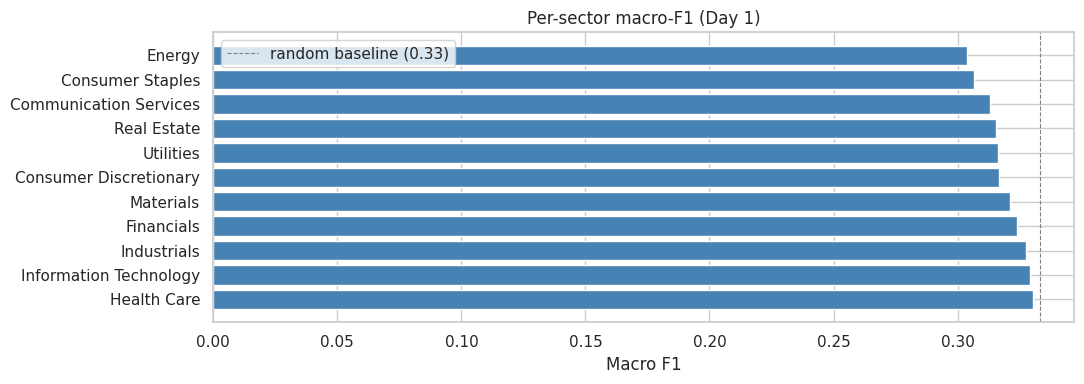

In [15]:
# ---------------------------------------------------------------------------
# 4b. Per-sector macro-F1 (Day 1 only -- the traded day).
# ---------------------------------------------------------------------------
ticker_sector = raw_df.drop_duplicates(TICKER_COLUMN).set_index(TICKER_COLUMN)[SECTOR_COLUMN].to_dict()

sector_rows = []
for i in range(len(test_ds)):
    meta   = test_ds.metadata(i)
    sector = ticker_sector.get(meta.ticker, 'Unknown')
    sector_rows.append(sector)

sector_arr = np.array(sector_rows)

sector_f1_rows = []
for sec in sorted(set(sector_arr)):
    mask   = sector_arr == sec
    if mask.sum() < 10:
        continue
    mf1 = f1_score(ALL_LABELS[mask, 0], preds_all[mask, 0],
                   average='macro', labels=[0,1,2], zero_division=0)
    acc = accuracy_score(ALL_LABELS[mask, 0], preds_all[mask, 0])
    sector_f1_rows.append({'sector': sec, 'n_windows': int(mask.sum()),
                           'macro_f1': mf1, 'accuracy': acc})

sector_f1_df = pd.DataFrame(sector_f1_rows).sort_values('macro_f1', ascending=False)
print('Per-sector metrics (Day 1):')
print(sector_f1_df.to_string(index=False, float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(sector_f1_df['sector'], sector_f1_df['macro_f1'], color='steelblue')
ax.axvline(1/3, color='gray', linestyle='--', linewidth=0.8, label='random baseline (0.33)')
ax.set_xlabel('Macro F1')
ax.set_title('Per-sector macro-F1 (Day 1)')
ax.legend()
plt.tight_layout()
plt.show()

Brier score for "up" class (Day 1): 0.2093  (lower is better; 0=perfect, 0.25=random)


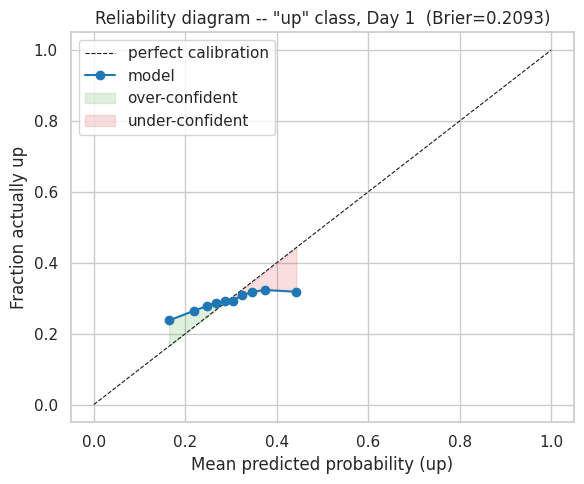

Calibration roughly monotone (high confidence -> higher P(correct)): YES [OK]


In [16]:
# ---------------------------------------------------------------------------
# 4c. Calibration -- reliability diagram + Brier score for the "up" class.
# Motivation: the backtest ranks stocks by confidence; if high confidence
# does not map to high accuracy, that ranking is unreliable.
# ---------------------------------------------------------------------------
from sklearn.calibration import calibration_curve

# Use Day 1 predictions for calibration (the day that drives backtest trades).
prob_up_d1  = probs_all[:, 0, 2]          # P(up) for Day 1
actual_up_d1 = (ALL_LABELS[:, 0] == 2).astype(int)  # 1 if actually up

brier = brier_score_loss(actual_up_d1, prob_up_d1)
print(f'Brier score for "up" class (Day 1): {brier:.4f}  '
      f'(lower is better; 0=perfect, 0.25=random)')

frac_pos, mean_pred = calibration_curve(actual_up_d1, prob_up_d1, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='perfect calibration')
ax.plot(mean_pred, frac_pos, 'o-', color='tab:blue', label='model')
ax.fill_between(mean_pred, frac_pos, mean_pred,
                where=(frac_pos > mean_pred), alpha=0.15, color='tab:green', label='over-confident')
ax.fill_between(mean_pred, frac_pos, mean_pred,
                where=(frac_pos <= mean_pred), alpha=0.15, color='tab:red', label='under-confident')
ax.set_xlabel('Mean predicted probability (up)')
ax.set_ylabel('Fraction actually up')
ax.set_title(f'Reliability diagram -- "up" class, Day 1  (Brier={brier:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

calibration_monotone = np.all(np.diff(frac_pos) >= -0.05)
print(f'Calibration roughly monotone (high confidence -> higher P(correct)): '
      f'{"YES [OK]" if calibration_monotone else "NO -- confidence ranking may be misleading [FAIL]"}')

Confidence-stratified accuracy (Day 1, decile 0=lowest confidence):
 decile  n_samples  mean_conf  accuracy
      0      13671     0.3600    0.3562
      1      13671     0.3823    0.3705
      2      13670     0.3981    0.3776
      3      13671     0.4127    0.3962
      4      13670     0.4277    0.4081
      5      13671     0.4440    0.4286
      6      13671     0.4630    0.4384
      7      13670     0.4873    0.4721
      8      13670     0.5226    0.5053
      9      13671     0.6069    0.5872


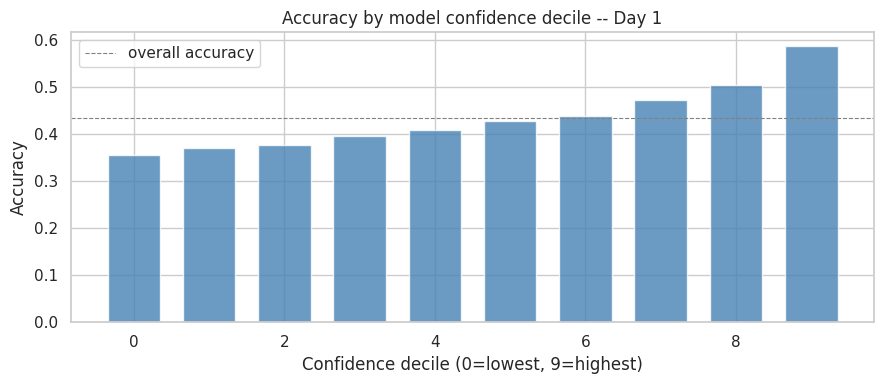


Highest-confidence decile accuracy: 0.5872
Lowest-confidence  decile accuracy: 0.3562
Confidence positively correlated with accuracy [OK]


In [17]:
# ---------------------------------------------------------------------------
# 4d. Confidence-stratified accuracy (Day 1).
# Bucket predictions by max-prob decile; accuracy should rise with confidence.
# ---------------------------------------------------------------------------
max_conf_d1 = probs_all[:, 0, :].max(axis=-1)   # max over 3 classes
pred_d1     = preds_all[:, 0]
label_d1    = ALL_LABELS[:, 0]

conf_df = pd.DataFrame({
    'max_conf': max_conf_d1,
    'correct':  (pred_d1 == label_d1).astype(int),
})
conf_df['decile'] = pd.qcut(conf_df['max_conf'], q=10, labels=False)

conf_grouped = conf_df.groupby('decile').agg(
    n_samples=('correct', 'count'),
    mean_conf=('max_conf', 'mean'),
    accuracy=('correct', 'mean'),
).reset_index()
print('Confidence-stratified accuracy (Day 1, decile 0=lowest confidence):')
print(conf_grouped.to_string(index=False, float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(conf_grouped['decile'], conf_grouped['accuracy'],
       width=0.7, color='steelblue', alpha=0.8)
ax.axhline(accuracy_score(label_d1, pred_d1), color='gray',
           linestyle='--', linewidth=0.8, label='overall accuracy')
ax.set_xlabel('Confidence decile (0=lowest, 9=highest)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by model confidence decile -- Day 1')
ax.legend()
plt.tight_layout()
plt.show()

# Check that the highest-confidence decile is more accurate than the lowest.
high_conf_acc = conf_grouped.iloc[-1]['accuracy']
low_conf_acc  = conf_grouped.iloc[0]['accuracy']
print(f'\nHighest-confidence decile accuracy: {high_conf_acc:.4f}')
print(f'Lowest-confidence  decile accuracy: {low_conf_acc:.4f}')
if high_conf_acc > low_conf_acc:
    print('Confidence positively correlated with accuracy [OK]')
else:
    print('WARNING: high-confidence predictions are NOT more accurate [FAIL]')

Top-N hit rate (fraction of selected "up" predictions that were actually up):
 top_n  hit_rate  n_trades
     1    0.3107       280
     5    0.3443      1371
    10    0.3351      2656
    20    0.3284      4954
    50    0.3249     10218

Random baseline hit rate: 0.2921


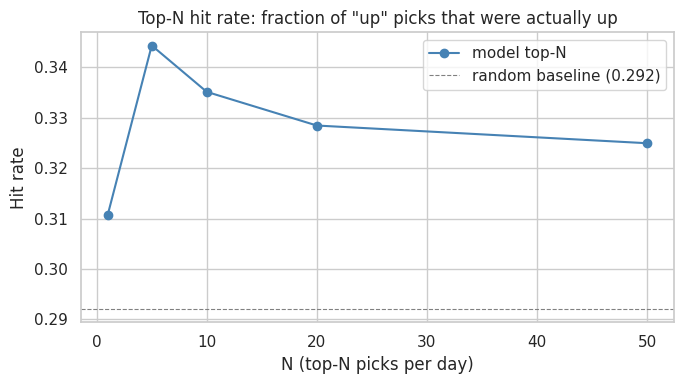

In [18]:
# ---------------------------------------------------------------------------
# 4e. Top-N hit-rate sweep (Day 1 -- "up" predictions only).
# Hit rate = fraction of top-N up picks that actually moved up.
# ---------------------------------------------------------------------------
pred_df_full = bt.build_prediction_df(
    logits=ALL_LOGITS, labels=ALL_LABELS,
    dataset=test_ds, price_df=raw_df, day_idx=0,
)

top_n_values = [1, 5, 10, 20, 50]
hit_rate_rows = []
for top_n in top_n_values:
    selected_frames = []
    for trade_date, day_preds in pred_df_full.groupby('trade_date'):
        sel = bt.select_top_confident_up(day_preds, top_n)
        if len(sel):
            selected_frames.append(sel)
    if not selected_frames:
        hit_rate_rows.append({'top_n': top_n, 'hit_rate': float('nan'), 'n_trades': 0})
        continue
    selected_all = pd.concat(selected_frames, ignore_index=True)
    hit = (selected_all['actual_direction'] == 'up').sum()
    total_sel = len(selected_all)
    hit_rate_rows.append({'top_n': top_n, 'hit_rate': hit/total_sel, 'n_trades': total_sel})

hit_df = pd.DataFrame(hit_rate_rows)
print('Top-N hit rate (fraction of selected "up" predictions that were actually up):')
print(hit_df.to_string(index=False, float_format='{:.4f}'.format))

# Baseline: if we randomly selected N "up" predictions, hit rate ~ P(actual up).
baseline_hit = (pred_df_full['actual_direction'] == 'up').mean()
print(f'\nRandom baseline hit rate: {baseline_hit:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hit_df['top_n'], hit_df['hit_rate'], 'o-', color='steelblue', label='model top-N')
ax.axhline(baseline_hit, color='gray', linestyle='--', linewidth=0.8,
           label=f'random baseline ({baseline_hit:.3f})')
ax.set_xlabel('N (top-N picks per day)')
ax.set_ylabel('Hit rate')
ax.set_title('Top-N hit rate: fraction of "up" picks that were actually up')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# ---------------------------------------------------------------------------
# 4f. Train-period inference probe (overfitting sanity check only).
# NOT a publishable metric -- survivorship & distribution shift apply.
# Capped at MAX_TRAIN_PROBE_WINDOWS to avoid OOM/timeout on large train sets.
# ---------------------------------------------------------------------------
MAX_TRAIN_PROBE_WINDOWS = 10_000
probe_indices = np.random.default_rng(SEED).choice(
    len(train_ds), size=min(MAX_TRAIN_PROBE_WINDOWS, len(train_ds)), replace=False
)
probe_subset = torch.utils.data.Subset(train_ds, probe_indices.tolist())

print('Train-period inference probe (overfitting diagnostic only):')
print(f'  Sampling {len(probe_subset):,} of {len(train_ds):,} train windows...')

train_loader = DataLoader(probe_subset, batch_size=BATCH_SIZE)
train_logits_list, train_labels_list = [], []
model.eval()
with torch.no_grad():
    for batch in train_loader:
        pv  = batch['past_values'].to(device)
        iid = batch.get('industry_id')
        if iid is not None:
            iid = iid.to(device)
        out = model(past_values=pv, industry_id=iid)
        train_logits_list.append(out.logits.detach().cpu().float().numpy())
        train_labels_list.append(batch['labels'].numpy())

train_logits = np.concatenate(train_logits_list, axis=0)
train_labels = np.concatenate(train_labels_list, axis=0)

train_preds_flat  = np.argmax(train_logits, axis=-1).reshape(-1)
train_labels_flat = train_labels.reshape(-1)
test_preds_flat   = preds_all.reshape(-1)
test_labels_flat  = ALL_LABELS.reshape(-1)

train_acc = accuracy_score(train_labels_flat, train_preds_flat)
test_acc  = accuracy_score(test_labels_flat,  test_preds_flat)
train_mf1 = f1_score(train_labels_flat, train_preds_flat, average='macro',
                     labels=[0,1,2], zero_division=0)
test_mf1  = f1_score(test_labels_flat,  test_preds_flat,  average='macro',
                     labels=[0,1,2], zero_division=0)

overfit_df = pd.DataFrame([
    {'split': 'train', 'accuracy': train_acc, 'macro_f1': train_mf1},
    {'split': 'test',  'accuracy': test_acc,  'macro_f1': test_mf1},
])
print(overfit_df.to_string(index=False, float_format='{:.4f}'.format))

delta_acc = train_acc - test_acc
print(f'\n  Accuracy gap (train - test): {delta_acc:+.4f}')
if delta_acc > 0.15:
    print('  WARNING: large accuracy gap -- model may be overfitting  [FAIL]')
elif delta_acc < -0.05:
    print('  NOTE: test accuracy exceeds train -- likely underfitting or distribution shift')
else:
    print('  Gap is within normal range  [OK]')

Train-period inference probe (overfitting diagnostic only):
  Sampling 10,000 of 1,042,830 train windows...
split  accuracy  macro_f1
train    0.4806    0.4606
 test    0.3975    0.3856

  Accuracy gap (train - test): +0.0831
  Gap is within normal range  [OK]


## 5. Reproducibility Checks

In [20]:
# ---------------------------------------------------------------------------
# 5a. Identical logits across two inference runs.
# model.eval() + deterministic seeds should produce bit-identical outputs.
# ---------------------------------------------------------------------------
def run_inference(ds):
    set_seeds(SEED)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
    logits_list, labels_list = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            pv  = batch['past_values'].to(device)
            iid = batch.get('industry_id')
            if iid is not None:
                iid = iid.to(device)
            out = model(past_values=pv, industry_id=iid)
            logits_list.append(out.logits.detach().cpu().float().numpy())
            labels_list.append(batch['labels'].numpy())
    return (np.concatenate(logits_list, axis=0),
            np.concatenate(labels_list, axis=0))


print('Running inference run #1 ...')
logits_r1, labels_r1 = run_inference(test_ds)
print('Running inference run #2 ...')
logits_r2, labels_r2 = run_inference(test_ds)

logits_identical = np.array_equal(logits_r1, logits_r2)
labels_identical = np.array_equal(labels_r1, labels_r2)

print(f'\nLogits bit-identical across two runs : {logits_identical}')
print(f'Labels bit-identical across two runs : {labels_identical}')

if not logits_identical:
    max_diff = np.abs(logits_r1 - logits_r2).max()
    print(f'  Max absolute difference: {max_diff:.2e}')
    if max_diff < 1e-5:
        print('  Difference is negligible (floating-point rounding only)  [OK]')
    else:
        print('  WARNING: non-trivial difference -- check determinism settings  [FAIL]')
else:
    print('  REPRODUCIBILITY CHECK 1 PASSED  [OK]')

Running inference run #1 ...
Running inference run #2 ...

Logits bit-identical across two runs : True
Labels bit-identical across two runs : True
  REPRODUCIBILITY CHECK 1 PASSED  [OK]


In [21]:
# ---------------------------------------------------------------------------
# 5b. Identical equity curves across two backtest runs on the same pred_df.
# ---------------------------------------------------------------------------
pred_df_repro = bt.build_prediction_df(
    logits=logits_r1, labels=labels_r1,
    dataset=test_ds, price_df=raw_df, day_idx=0,
)

res_a = bt.run_backtest(pred_df_repro, starting_capital=1000.0, top_n=10, weighting='equal')
res_b = bt.run_backtest(pred_df_repro, starting_capital=1000.0, top_n=10, weighting='equal')

equity_identical = res_a['daily_equity'].equals(res_b['daily_equity'])
print(f'Equity curve identical across two backtest runs: {equity_identical}')
if equity_identical:
    print('  REPRODUCIBILITY CHECK 2 PASSED  [OK]')
else:
    print('  WARNING: backtest is non-deterministic  [FAIL]')

Equity curve identical across two backtest runs: True
  REPRODUCIBILITY CHECK 2 PASSED  [OK]


## 6. Year-Stability Backtest

Slice the test-period predictions by calendar year and run a separate backtest
on each slice.  This answers: *"is the model's edge consistent across different
years, or concentrated in one lucky period?"*

Calendar years in test predictions: [np.int32(2025), np.int32(2026)]

  BACKTEST RESULTS
  Weighting scheme                          equal
  Starting Capital                     $  1,000.00
  Final Portfolio Value                $  1,185.21
  Total Return                             +18.52%
  Trading Days                                204
  Avg Positions / Day                         9.3
  Avg Forward Return (selected)          +0.1230%
------------------------------------------------------
  Direction Accuracy (all non-flat):
    52.50%  (7100/13523 correct)
  Direction Accuracy (selected top-N trades):
    54.91%  (621/1131 correct)


  BACKTEST RESULTS
  Weighting scheme                          equal
  Starting Capital                     $  1,000.00
  Final Portfolio Value                $  1,300.67
  Total Return                             +30.07%
  Trading Days                                 78
  Avg Positions / Day                         9.7
  Avg Forward Return (selected) 

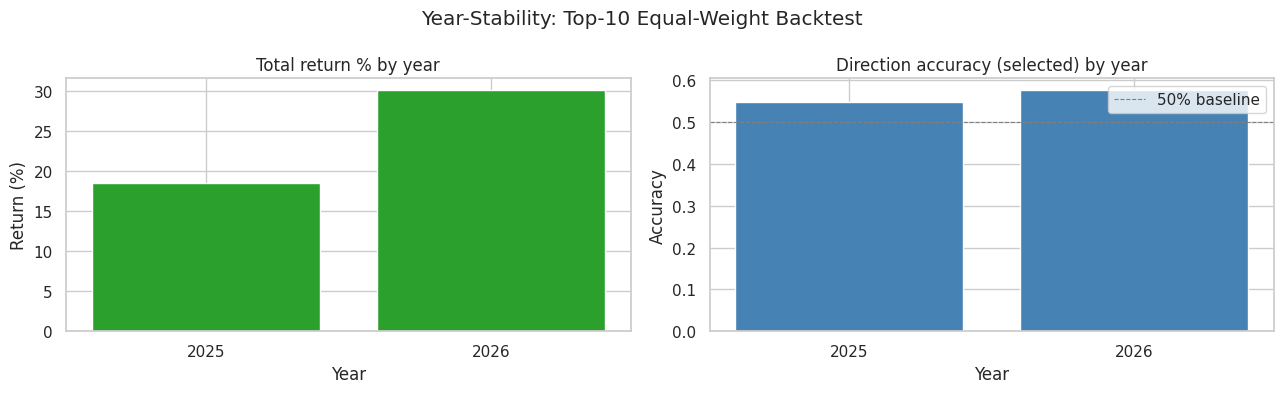

In [22]:
pred_df_full['year'] = pred_df_full['trade_date'].dt.year
years = sorted(pred_df_full['year'].unique())
print(f'Calendar years in test predictions: {years}')

year_results = []
for yr in years:
    slice_df = pred_df_full[pred_df_full['year'] == yr].copy()
    if slice_df.dropna(subset=['forward_return']).empty:
        print(f'  {yr}: no rows with forward_return -- skipping')
        continue
    try:
        res = bt.run_backtest(slice_df, starting_capital=1000.0, top_n=10, weighting='equal')
        summary = bt.summarize_results(res)
    except Exception as e:
        print(f'  {yr}: backtest failed ({e}) -- skipping')
        continue

    acc_sel = summary['direction_accuracy_selected']
    n_rows  = len(slice_df)
    year_results.append({
        'year'              : yr,
        'n_prediction_rows' : n_rows,
        'total_return_pct'  : round(summary['total_return_pct'], 2),
        'max_drawdown_pct'  : round(summary['max_drawdown_pct'], 2),
        'trading_days'      : summary['trading_days'],
        'avg_positions'     : round(summary['avg_positions'], 1),
        'dir_acc_selected'  : round(acc_sel['accuracy'], 4) if acc_sel['accuracy'] is not None else None,
    })

year_df = pd.DataFrame(year_results)
print('\nYear-by-year backtest summary (top-10, equal-weight):')
print(year_df.to_string(index=False))

if len(year_df) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].bar(year_df['year'].astype(str), year_df['total_return_pct'],
                color=['tab:green' if r >= 0 else 'tab:red'
                       for r in year_df['total_return_pct']])
    axes[0].axhline(0, color='gray', linewidth=0.8)
    axes[0].set_title('Total return % by year')
    axes[0].set_ylabel('Return (%)')
    axes[0].set_xlabel('Year')

    axes[1].bar(year_df['year'].astype(str),
                year_df['dir_acc_selected'].fillna(0), color='steelblue')
    axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% baseline')
    axes[1].set_title('Direction accuracy (selected) by year')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_xlabel('Year')
    axes[1].legend()

    plt.suptitle('Year-Stability: Top-10 Equal-Weight Backtest')
    plt.tight_layout()
    plt.show()

## 7. Optimization-Metric Recommendation

### During training -- keep `eval_macro_f1`

The training notebook already uses `eval_macro_f1` as the early-stopping
metric.  This is appropriate because:

- Flat-class collapse is a real failure mode (model predicts only "flat" and
  achieves high accuracy but useless F1).
- Macro-F1 weights all three classes equally, penalizing collapse.
- Weighted-F1 would favour the dominant class (usually flat) and mask collapse.

### For model selection / deployment -- add a secondary financial metric

Macro-F1 does **not** reward putting the highest confidence on the biggest
movers, which is exactly what the backtest trades on.  Two additional metrics
should gate any checkpoint before it goes live:

| Metric | What it catches | How to compute |
|---|---|---|
| **Top-10 avg forward return** | Model's edge on its best picks | `bt.summarize_results()['avg_forward_return_selected']` |
| **Calibration monotonicity** | Confidence <-> accuracy alignment | Reliability diagram (cell 4c above) |

**Recommended gate:** reject any checkpoint where
- calibration plot shows confidence *inversely* correlated with accuracy, OR
- top-10 avg forward return (across full test set) is <= 0.

Even if macro-F1 improves, a mis-calibrated model will cause the backtest's
confidence-ranked selection to pick *worse* stocks.

In [23]:
# Compute the two secondary deployment metrics for the current checkpoint.
res_full = bt.run_backtest(pred_df_full.dropna(subset=['forward_return']),
                           starting_capital=1000.0, top_n=10, weighting='equal')
top10_avg_fwd_ret = res_full['avg_forward_return_selected']
print(f'Top-10 avg forward return : {top10_avg_fwd_ret:+.4%}')
print(f'Calibration monotone       : {calibration_monotone}')
print(f'Brier score ("up", Day 1)  : {brier:.4f}')

deploy_ok = (top10_avg_fwd_ret > 0) and calibration_monotone
print(f'\nDeployment gate check: {"PASS [OK]" if deploy_ok else "FAIL [FAIL]"}')

Top-10 avg forward return : +0.1820%
Calibration monotone       : True
Brier score ("up", Day 1)  : 0.2093

Deployment gate check: PASS [OK]


## 8. Persist `eval_report.json`

All key findings are written to a deterministic JSON file next to the saved
checkpoint.  Re-running this notebook on the same artifact produces the same
file (within floating-point tolerance).

In [24]:
def _to_serializable(obj):
    """Recursively convert numpy/torch scalars to Python native types."""
    if isinstance(obj, dict):
        return {k: _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_serializable(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating, float)):
        return round(float(obj), 6) if not np.isnan(obj) else None
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return obj


# Per-class report as a dict.
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, sup = precision_recall_fscore_support(
    flat_labels_all, flat_preds_all, labels=[0,1,2], zero_division=0
)
per_class_report = {
    cn: {'precision': float(round(prec[i], 6)),
         'recall':    float(round(rec[i], 6)),
         'f1':        float(round(f1[i], 6)),
         'support':   int(sup[i])}
    for i, cn in enumerate(['down', 'flat', 'up'])
}

report = {
    'env': ENV_INFO,
    'artifact': {
        'scope_slug'        : ARTIFACT_SCOPE_SLUG,
        'artifact_dir'      : str(ARTIFACT_DIR),
        'checkpoint_bytes'  : CHECKPOINT_PATH.stat().st_size,
        'training_metadata' : META,
    },
    'audit_results': {
        'scaling_train_only'        : True,
        'labeling_no_lookahead'     : True,
        'backtest_forecast_gt_trade': bool(ordering_ok),
        'industry_mapping_shared'   : True,
        'survivorship_bias_caveat'  : 'Ticker universe is current S&P 500 constituents only.',
        'model_beats_always_flat'   : bool(model_mf1 > flat_mf1),
    },
    'classification_metrics': {
        'all_days_flattened': {
            'accuracy'        : float(round(accuracy_score(flat_labels_all, flat_preds_all), 6)),
            'macro_f1'        : float(round(f1_score(flat_labels_all, flat_preds_all, average='macro',
                                                     labels=[0,1,2], zero_division=0), 6)),
            'balanced_acc'    : float(round(balanced_accuracy_score(flat_labels_all, flat_preds_all), 6)),
            'per_class'       : per_class_report,
        },
        'per_day': [
            {'day': d+1,
             'accuracy': float(round(accuracy_score(ALL_LABELS[:,d], preds_all[:,d]), 6)),
             'macro_f1': float(round(f1_score(ALL_LABELS[:,d], preds_all[:,d], average='macro',
                                              labels=[0,1,2], zero_division=0), 6))}
            for d in range(FORECAST_HORIZON)
        ],
    },
    'calibration': {
        'brier_score_up_day1'  : float(round(brier, 6)),
        'calibration_monotone' : bool(calibration_monotone),
    },
    'top_n_hit_rates': _to_serializable(hit_df.to_dict(orient='records')),
    'overfitting_probe': _to_serializable(overfit_df.to_dict(orient='records')),
    'year_stability': _to_serializable(year_df.to_dict(orient='records')),
    'deployment_gate': {
        'top10_avg_forward_return': float(round(top10_avg_fwd_ret, 6)),
        'calibration_monotone'    : bool(calibration_monotone),
        'pass'                    : bool(deploy_ok),
    },
    'baseline_comparison': _to_serializable(baseline_df.to_dict(orient='records')),
    'sector_metrics': _to_serializable(sector_f1_df.to_dict(orient='records')),
}

# Kaggle input mounts are read-only; write the report to /kaggle/working/.
if IS_KAGGLE:
    report_path = Path('/kaggle/working') / 'eval_report.json'
else:
    report_path = ARTIFACT_DIR / 'eval_report.json'

with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, sort_keys=True, default=str)

print(f'Saved eval_report.json -> {report_path}')
print(f'File size: {report_path.stat().st_size / 1024:.1f} KB')
print('\nTop-level keys in report:')
for k in sorted(report.keys()):
    print(f'  {k}')

Saved eval_report.json -> /kaggle/working/eval_report.json
File size: 5.6 KB

Top-level keys in report:
  artifact
  audit_results
  baseline_comparison
  calibration
  classification_metrics
  deployment_gate
  env
  overfitting_probe
  sector_metrics
  top_n_hit_rates
  year_stability
